## Intialization

In [12]:
## Libraries
import os
import cv2 
import numpy as np
import pandas as pd  

import matplotlib.pyplot as plt 
%matplotlib inline 

from sklearn.model_selection import train_test_split,KFold

import tensorflow as tf 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import backend as K

In [2]:
## Variables

IMG_HEIGHT = 512
IMG_WIDTH = 512
IMG_CHANNEL = 3
IMG_PATH = './Dataset/Images/'
MASK_PATH = './Dataset/GT/'

img_dim = (512, 512, 3)

### Preprocessing

In [3]:
# Geting data

img_files = os.listdir(IMG_PATH)
mask_files = os.listdir(MASK_PATH)

X = np.zeros((len(img_files), IMG_WIDTH, IMG_HEIGHT, IMG_CHANNEL), dtype=np.float32)
Y = np.zeros((len(img_files), IMG_WIDTH, IMG_HEIGHT, 1), dtype=np.uint8)


for i, img_file in enumerate(img_files):
    
    # Image
    image = cv2.imread(IMG_PATH + img_file)
    image = cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH), interpolation = cv2.INTER_LINEAR)
    X[i,:,:,:] = image/255.

    # Mask
    mask = cv2.imread(MASK_PATH + 'gt_c' + str(img_file[:-4]) + '.jpg')
    mask = cv2.resize(mask, (IMG_HEIGHT, IMG_WIDTH), interpolation = cv2.INTER_LINEAR)
    Y[i,:,:,:] = np.expand_dims(mask[:,:,0], axis=-1)/255.

# Spliting dataset train/test
idx_train, idx_test = train_test_split(range(0, len(img_files)), test_size = 0.3, random_state = 42)


In [4]:
X.shape, Y.shape

((50, 512, 512, 3), (50, 512, 512, 1))

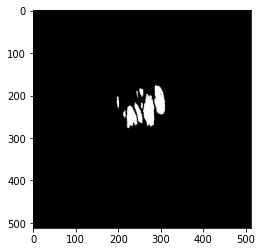

In [5]:
plt.imshow(Y[14], cmap = 'gray')

### Attention Unet Build

In [6]:
## Model

def attention_gate(inp_1, inp_2, n_intermediate_filters):
    inp_1_conv = tf.keras.layers.Conv2D(n_intermediate_filters, kernel_size = 1, strides = 1, padding = "same",
                                        kernel_initializer = "he_normal") (inp_1)
    inp_2_conv = tf.keras.layers.Conv2D(n_intermediate_filters, kernel_size = 1, strides = 1, padding = "same",
                                        kernel_initializer = "he_normal") (inp_2)
    f = tf.keras.layers.Activation("gelu") (tf.keras.layers.add([inp_1_conv, inp_2_conv]))
    g = tf.keras.layers.Conv2D(filters = 1, kernel_size = 1, strides = 1, padding = "same", 
                               kernel_initializer = "he_normal") (f)
    h = tf.keras.layers.Activation("sigmoid") (g)
    return tf.keras.layers.multiply([inp_1, h])

def attention_concat(conv_below, skip_connection):
    below_filters = conv_below.get_shape().as_list()[-1]
    attention_across = attention_gate(skip_connection, conv_below, below_filters)
    return tf.keras.layers.concatenate([conv_below, attention_across])

def upsample_conv(filters, kernel_size, strides, padding):
    return tf.keras.layers.Conv2DTranspose(filters, kernel_size, strides = strides, padding = padding)

def conv2d_block(inputs, filters = 16, kernel_size = (3, 3), activation = "relu",
                 kernel_initializer = "he_normal", padding = "same"):
    c = tf.keras.layers.Conv2D(filters, kernel_size, activation = activation, kernel_initializer = kernel_initializer,
                               padding = padding, use_bias = False) (inputs)
    c = tf.keras.layers.BatchNormalization() (c)
    c = tf.keras.layers.SpatialDropout2D(0.3) (c)
    c = tf.keras.layers.Conv2D(filters, kernel_size, activation = activation, kernel_initializer = kernel_initializer,
                               padding = padding, use_bias = False) (c)
    c = tf.keras.layers.BatchNormalization()(c)
    return c

def custom_unet(input_shape, num_classes = 1, activation = "relu", filters = 16, num_layers = 3):
    inputs = tf.keras.layers.Input(input_shape)
    x = inputs

    down_layers = []
    for l in range(num_layers):
        x = conv2d_block(inputs = x, filters = filters, activation = activation)
        down_layers.append(x)
        x = tf.keras.layers.MaxPooling2D((2, 2))(x)
        filters = filters * 2

    x = conv2d_block(inputs = x, filters = filters, activation = activation)

    for conv in reversed(down_layers):
        filters //= 2
        x = upsample_conv(filters, (2, 2), strides = (2, 2), padding = "same") (x)
        x = attention_concat(conv_below = x, skip_connection = conv)
        x = conv2d_block(inputs = x, filters = filters, activation = activation)

    outputs = tf.keras.layers.Conv2D(num_classes, (3, 3), activation = 'sigmoid', padding = 'same') (x)

    model = tf.keras.models.Model(inputs = [inputs], outputs = [outputs])
    return model


In [7]:
## Metrics
def iou(y_true, y_pred, smooth = 1.):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection + smooth)

def threshold_binarize(x, threshold = 0.5):
    ge = tf.greater_equal(x, tf.constant(threshold))
    y = tf.where(ge, x = tf.ones_like(x), y = tf.zeros_like(x))
    return y
def iou_thresholded(y_true, y_pred, threshold = 0.3, smooth = 1.):
    y_pred = threshold_binarize(y_pred, threshold)
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection + smooth)

# Losses
def focal_loss(gamma = 2., alpha = .25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.keras.backend.mean(alpha * tf.keras.backend.pow(1. - pt_1, gamma) \
                                      * tf.keras.backend.log(pt_1 + tf.keras.backend.epsilon())) \
                - tf.keras.backend.mean((1 - alpha) * tf.keras.backend.pow(pt_0, gamma) \
                                        * tf.keras.backend.log(1. - pt_0 + tf.keras.backend.epsilon()))
    return focal_loss_fixed

def tversky(y_true: tf.Tensor, 
            y_pred: tf.Tensor, 
            smooth: int = 1, 
            alpha: float = 0.7) -> float:
    y_true_pos = tf.keras.backend.flatten(y_true)
    y_pred_pos = tf.keras.backend.flatten(y_pred)
    true_pos = tf.keras.backend.sum(y_true_pos * y_pred_pos)
    false_neg = tf.keras.backend.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = tf.keras.backend.sum((1 - y_true_pos) * y_pred_pos)
    return (true_pos + smooth) / (true_pos + alpha * false_neg +
                                  (1 - alpha) * false_pos + smooth)


def tversky_loss(y_true: tf.Tensor, 
                 y_pred: tf.Tensor) -> float:
    return 1 - tversky(y_true, y_pred)


def focal_tversky_loss(y_true: tf.Tensor, 
                       y_pred: tf.Tensor, 
                       gamma:float = 0.75) -> float:
    y_true = tf.cast(y_true, dtype=y_pred.dtype)
    tv = tversky(y_true, y_pred)
    return tf.keras.backend.pow((1 - tv), gamma)



## Segmentation model training

C:\Users\SOFIA\Anaconda3\lib\site-packages\tensorflow\python\data\ops\dataset_ops.py:3504: UserWarning: Even though the tf.config.experimental_run_functions_eagerly option is set, this option does not apply to tf.data functions. tf.data functions are still traced and executed as graphs.
  "Even though the tf.config.experimental_run_functions_eagerly "


Epoch 1/300
45/45 [==============================] - 27s 308ms/step - loss: 0.9589 - iou: 0.0174 - iou_thresholded: 0.0149 - val_loss: 0.9755 - val_iou: 0.0120 - val_iou_thresholded: 6.3188e-04

Epoch 00001: val_iou_thresholded improved from -inf to 0.00063, saving model to .\1_best_model.h5
Epoch 2/300
45/45 [==============================] - 15s 329ms/step - loss: 0.9014 - iou: 0.0442 - iou_thresholded: 0.0537 - val_loss: 0.9938 - val_iou: 0.0044 - val_iou_thresholded: 0.0031

Epoch 00002: val_iou_thresholded improved from 0.00063 to 0.00312, saving model to .\1_best_model.h5
Epoch 3/300
45/45 [==============================] - 15s 328ms/step - loss: 0.8413 - iou: 0.0770 - iou_thresholded: 0.1072 - val_loss: 0.9974 - val_iou: 0.0018 - val_iou_thresholded: 0.0031

Epoch 00003: val_iou_thresholded did not improve from 0.00312
Epoch 4/300
45/45 [==============================] - 15s 337ms/step - loss: 0.7467 - iou: 0.1366 - iou_thresholded: 0.1773 - val_loss: 0.9971 - val_iou: 0.0020 - 

45/45 [==============================] - 9s 211ms/step - loss: 0.3061 - iou: 0.6172 - iou_thresholded: 0.6167 - val_loss: 0.7703 - val_iou: 0.2076 - val_iou_thresholded: 0.2092

Epoch 00032: val_iou_thresholded did not improve from 0.27109
Epoch 33/300
45/45 [==============================] - 10s 221ms/step - loss: 0.2865 - iou: 0.6454 - iou_thresholded: 0.6448 - val_loss: 0.7163 - val_iou: 0.2229 - val_iou_thresholded: 0.2230

Epoch 00033: val_iou_thresholded did not improve from 0.27109
Epoch 34/300
45/45 [==============================] - 9s 205ms/step - loss: 0.2904 - iou: 0.6395 - iou_thresholded: 0.6392 - val_loss: 0.6198 - val_iou: 0.3388 - val_iou_thresholded: 0.3389

Epoch 00034: val_iou_thresholded improved from 0.27109 to 0.33891, saving model to .\1_best_model.h5
Epoch 35/300
45/45 [==============================] - 11s 235ms/step - loss: 0.2753 - iou: 0.6592 - iou_thresholded: 0.6586 - val_loss: 0.8791 - val_iou: 0.1141 - val_iou_thresholded: 0.1151

Epoch 00035: val_iou_t

45/45 [==============================] - 8s 186ms/step - loss: 0.2635 - iou: 0.6684 - iou_thresholded: 0.6677 - val_loss: 0.7050 - val_iou: 0.2493 - val_iou_thresholded: 0.2487

Epoch 00063: val_iou_thresholded did not improve from 0.33891
Epoch 64/300
45/45 [==============================] - 8s 184ms/step - loss: 0.2336 - iou: 0.7141 - iou_thresholded: 0.7137 - val_loss: 0.6923 - val_iou: 0.2557 - val_iou_thresholded: 0.2555

Epoch 00064: val_iou_thresholded did not improve from 0.33891
Epoch 65/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2472 - iou: 0.6966 - iou_thresholded: 0.6964 - val_loss: 0.6935 - val_iou: 0.2538 - val_iou_thresholded: 0.2539

Epoch 00065: val_iou_thresholded did not improve from 0.33891
Epoch 66/300
45/45 [==============================] - 8s 184ms/step - loss: 0.2631 - iou: 0.6547 - iou_thresholded: 0.6539 - val_loss: 0.6921 - val_iou: 0.2558 - val_iou_thresholded: 0.2560

Epoch 00066: val_iou_thresholded did not improve from 0.33891
E

45/45 [==============================] - 8s 183ms/step - loss: 0.2714 - iou: 0.6503 - iou_thresholded: 0.6496 - val_loss: 0.6986 - val_iou: 0.2489 - val_iou_thresholded: 0.2493

Epoch 00095: val_iou_thresholded did not improve from 0.33891
Epoch 96/300
45/45 [==============================] - 9s 191ms/step - loss: 0.2330 - iou: 0.7061 - iou_thresholded: 0.7057 - val_loss: 0.7399 - val_iou: 0.2225 - val_iou_thresholded: 0.2226

Epoch 00096: val_iou_thresholded did not improve from 0.33891
Epoch 97/300
45/45 [==============================] - 8s 185ms/step - loss: 0.2536 - iou: 0.6896 - iou_thresholded: 0.6894 - val_loss: 0.7034 - val_iou: 0.2452 - val_iou_thresholded: 0.2459

Epoch 00097: val_iou_thresholded did not improve from 0.33891
Epoch 98/300
45/45 [==============================] - 8s 187ms/step - loss: 0.2469 - iou: 0.6833 - iou_thresholded: 0.6826 - val_loss: 0.6944 - val_iou: 0.2507 - val_iou_thresholded: 0.2513

Epoch 00098: val_iou_thresholded did not improve from 0.33891
E

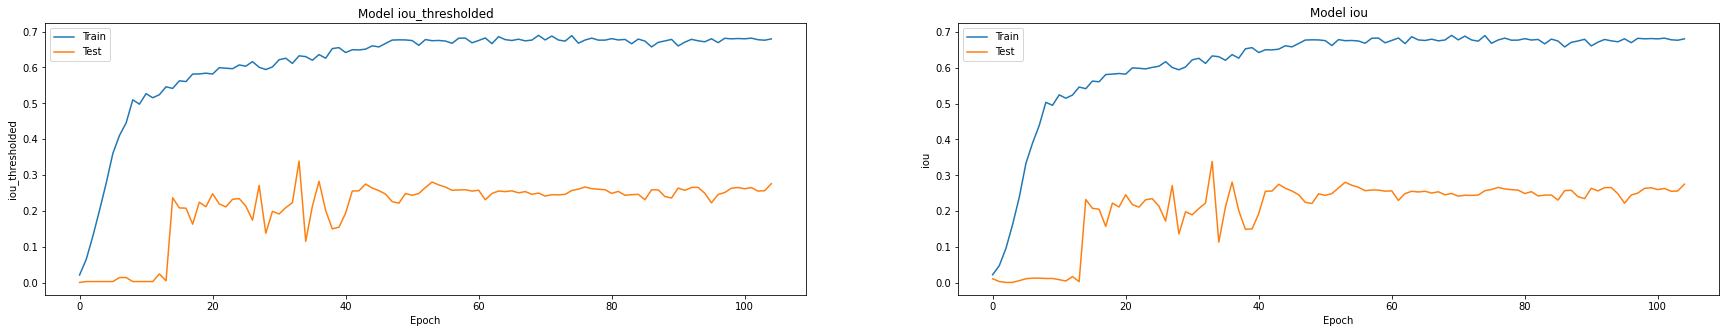

Epoch 1/300
45/45 [==============================] - 9s 190ms/step - loss: 0.9510 - iou: 0.0210 - iou_thresholded: 0.0174 - val_loss: 0.9696 - val_iou: 0.0135 - val_iou_thresholded: 1.6565e-04

Epoch 00001: val_iou_thresholded improved from -inf to 0.00017, saving model to .\2_best_model.h5
Epoch 2/300
45/45 [==============================] - 8s 187ms/step - loss: 0.9378 - iou: 0.0272 - iou_thresholded: 0.0292 - val_loss: 0.9812 - val_iou: 0.0103 - val_iou_thresholded: 5.9123e-04

Epoch 00002: val_iou_thresholded improved from 0.00017 to 0.00059, saving model to .\2_best_model.h5
Epoch 3/300
45/45 [==============================] - 9s 192ms/step - loss: 0.8674 - iou: 0.0618 - iou_thresholded: 0.0822 - val_loss: 0.9916 - val_iou: 0.0058 - val_iou_thresholded: 5.9289e-04s: 0.8669 - iou: 0.0620 - iou_thresholded: 0.0

Epoch 00003: val_iou_thresholded improved from 0.00059 to 0.00059, saving model to .\2_best_model.h5
Epoch 4/300
45/45 [==============================] - 8s 185ms/step - los

45/45 [==============================] - 9s 189ms/step - loss: 0.3140 - iou: 0.6194 - iou_thresholded: 0.6195 - val_loss: 0.3762 - val_iou: 0.5001 - val_iou_thresholded: 0.4987 0.3084 - iou: 0.6292 

Epoch 00030: val_iou_thresholded did not improve from 0.53642
Epoch 31/300
45/45 [==============================] - 8s 187ms/step - loss: 0.2996 - iou: 0.6225 - iou_thresholded: 0.6217 - val_loss: 0.3565 - val_iou: 0.5256 - val_iou_thresholded: 0.5242

Epoch 00031: val_iou_thresholded did not improve from 0.53642
Epoch 32/300
45/45 [==============================] - 9s 190ms/step - loss: 0.3438 - iou: 0.5751 - iou_thresholded: 0.5741 - val_loss: 0.4519 - val_iou: 0.4865 - val_iou_thresholded: 0.4877

Epoch 00032: val_iou_thresholded did not improve from 0.53642
Epoch 33/300
45/45 [==============================] - 8s 189ms/step - loss: 0.3450 - iou: 0.5708 - iou_thresholded: 0.5703 - val_loss: 0.3771 - val_iou: 0.5268 - val_iou_thresholded: 0.5266

Epoch 00033: val_iou_thresholded did not 


Epoch 00060: val_iou_thresholded did not improve from 0.55872
Epoch 61/300
45/45 [==============================] - 8s 182ms/step - loss: 0.2844 - iou: 0.6445 - iou_thresholded: 0.6434 - val_loss: 0.4242 - val_iou: 0.5253 - val_iou_thresholded: 0.5269

Epoch 00061: val_iou_thresholded did not improve from 0.55872
Epoch 62/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2791 - iou: 0.6529 - iou_thresholded: 0.6520 - val_loss: 0.4127 - val_iou: 0.5347 - val_iou_thresholded: 0.5363

Epoch 00062: val_iou_thresholded did not improve from 0.55872
Epoch 63/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2601 - iou: 0.6846 - iou_thresholded: 0.6845 - val_loss: 0.4008 - val_iou: 0.5442 - val_iou_thresholded: 0.5455

Epoch 00063: val_iou_thresholded did not improve from 0.55872
Epoch 64/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2971 - iou: 0.6298 - iou_thresholded: 0.6293 - val_loss: 0.4067 - val_iou: 0.5390 - val_iou_threshol

45/45 [==============================] - 9s 190ms/step - loss: 0.2829 - iou: 0.6494 - iou_thresholded: 0.6488 - val_loss: 0.4076 - val_iou: 0.5380 - val_iou_thresholded: 0.5397

Epoch 00093: val_iou_thresholded did not improve from 0.55872
Epoch 94/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2632 - iou: 0.6656 - iou_thresholded: 0.6652 - val_loss: 0.4176 - val_iou: 0.5304 - val_iou_thresholded: 0.5319

Epoch 00094: val_iou_thresholded did not improve from 0.55872
Epoch 95/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2510 - iou: 0.6819 - iou_thresholded: 0.6807 - val_loss: 0.4086 - val_iou: 0.5372 - val_iou_thresholded: 0.5394

Epoch 00095: val_iou_thresholded did not improve from 0.55872
Epoch 96/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2669 - iou: 0.6647 - iou_thresholded: 0.6643 - val_loss: 0.4097 - val_iou: 0.5366 - val_iou_thresholded: 0.5385

Epoch 00096: val_iou_thresholded did not improve from 0.55872
E

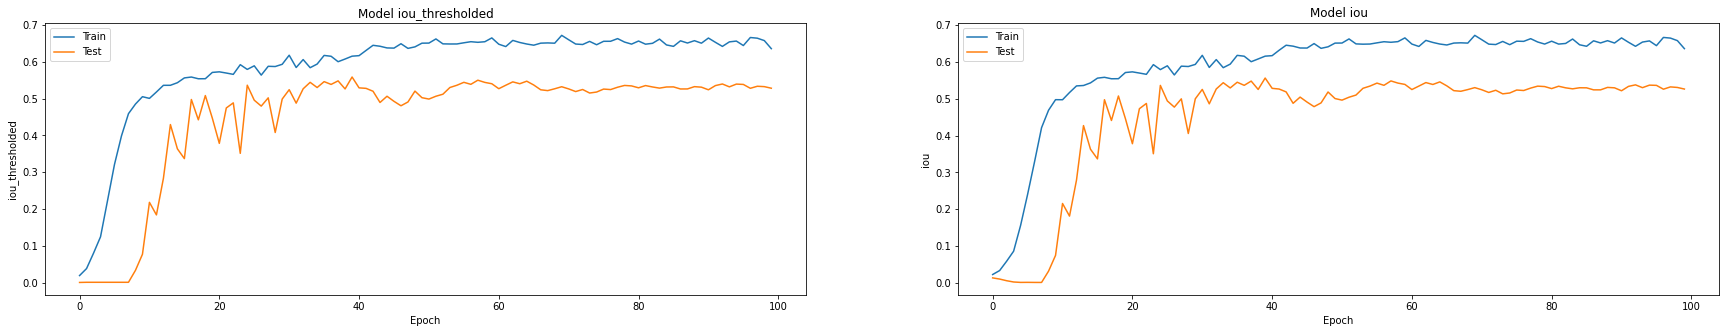

Epoch 1/300
45/45 [==============================] - 9s 188ms/step - loss: 0.9464 - iou: 0.0232 - iou_thresholded: 0.0218 - val_loss: 0.9847 - val_iou: 0.0068 - val_iou_thresholded: 0.0011

Epoch 00001: val_iou_thresholded improved from -inf to 0.00114, saving model to .\3_best_model.h5
Epoch 2/300
45/45 [==============================] - 8s 187ms/step - loss: 0.8540 - iou: 0.0690 - iou_thresholded: 0.0972 - val_loss: 0.9918 - val_iou: 0.0047 - val_iou_thresholded: 0.0011

Epoch 00002: val_iou_thresholded improved from 0.00114 to 0.00115, saving model to .\3_best_model.h5
Epoch 3/300
45/45 [==============================] - 8s 186ms/step - loss: 0.8031 - iou: 0.1017 - iou_thresholded: 0.1360 - val_loss: 0.9958 - val_iou: 0.0029 - val_iou_thresholded: 0.0011

Epoch 00003: val_iou_thresholded did not improve from 0.00115
Epoch 4/300
45/45 [==============================] - 8s 188ms/step - loss: 0.7065 - iou: 0.1707 - iou_thresholded: 0.2064 - val_loss: 0.9975 - val_iou: 0.0019 - val_iou_

45/45 [==============================] - 9s 194ms/step - loss: 0.2721 - iou: 0.6561 - iou_thresholded: 0.6555 - val_loss: 0.4704 - val_iou: 0.5248 - val_iou_thresholded: 0.5267

Epoch 00031: val_iou_thresholded did not improve from 0.55295
Epoch 32/300
45/45 [==============================] - 9s 190ms/step - loss: 0.2885 - iou: 0.6347 - iou_thresholded: 0.6341 - val_loss: 0.4658 - val_iou: 0.5309 - val_iou_thresholded: 0.5324

Epoch 00032: val_iou_thresholded did not improve from 0.55295
Epoch 33/300
45/45 [==============================] - 8s 186ms/step - loss: 0.3021 - iou: 0.6277 - iou_thresholded: 0.6271 - val_loss: 0.4635 - val_iou: 0.5231 - val_iou_thresholded: 0.5241

Epoch 00033: val_iou_thresholded did not improve from 0.55295
Epoch 34/300
45/45 [==============================] - 8s 183ms/step - loss: 0.3013 - iou: 0.6291 - iou_thresholded: 0.6285 - val_loss: 0.4663 - val_iou: 0.5244 - val_iou_thresholded: 0.52549 - iou: 0.6210 - iou_

Epoch 00034: val_iou_thresholded did not 

45/45 [==============================] - 8s 187ms/step - loss: 0.2957 - iou: 0.6316 - iou_thresholded: 0.6308 - val_loss: 0.4637 - val_iou: 0.5298 - val_iou_thresholded: 0.5326

Epoch 00063: val_iou_thresholded did not improve from 0.55295
Epoch 64/300
45/45 [==============================] - 8s 187ms/step - loss: 0.3084 - iou: 0.6077 - iou_thresholded: 0.6066 - val_loss: 0.4622 - val_iou: 0.5315 - val_iou_thresholded: 0.5345ou: 0.5952 - iou

Epoch 00064: val_iou_thresholded did not improve from 0.55295
Epoch 65/300
45/45 [==============================] - 8s 188ms/step - loss: 0.2869 - iou: 0.6432 - iou_thresholded: 0.6425 - val_loss: 0.4548 - val_iou: 0.5373 - val_iou_thresholded: 0.5398

Epoch 00065: val_iou_thresholded did not improve from 0.55295
Epoch 66/300
45/45 [==============================] - 8s 185ms/step - loss: 0.3507 - iou: 0.5697 - iou_thresholded: 0.5688 - val_loss: 0.4477 - val_iou: 0.5341 - val_iou_thresholded: 0.5340

Epoch 00066: val_iou_thresholded did not improv

45/45 [==============================] - 8s 184ms/step - loss: 0.2624 - iou: 0.6708 - iou_thresholded: 0.6709 - val_loss: 0.4499 - val_iou: 0.5278 - val_iou_thresholded: 0.5283

Epoch 00095: val_iou_thresholded did not improve from 0.55295
Epoch 96/300
45/45 [==============================] - 8s 182ms/step - loss: 0.2719 - iou: 0.6687 - iou_thresholded: 0.6683 - val_loss: 0.4487 - val_iou: 0.5317 - val_iou_thresholded: 0.5323

Epoch 00096: val_iou_thresholded did not improve from 0.55295
Epoch 97/300
45/45 [==============================] - 8s 184ms/step - loss: 0.2747 - iou: 0.6669 - iou_thresholded: 0.6659 - val_loss: 0.4561 - val_iou: 0.5376 - val_iou_thresholded: 0.5400

Epoch 00097: val_iou_thresholded did not improve from 0.55295
Epoch 98/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2936 - iou: 0.6300 - iou_thresholded: 0.6293 - val_loss: 0.4506 - val_iou: 0.5407 - val_iou_thresholded: 0.5430

Epoch 00098: val_iou_thresholded did not improve from 0.55295


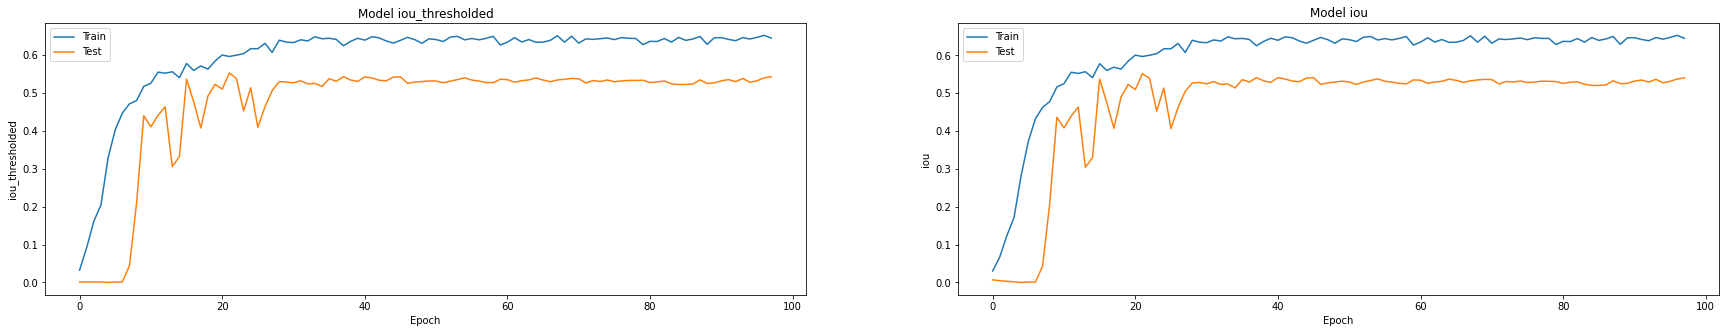

Epoch 1/300
45/45 [==============================] - 8s 184ms/step - loss: 0.9533 - iou: 0.0201 - iou_thresholded: 0.0168 - val_loss: 0.9782 - val_iou: 0.0093 - val_iou_thresholded: 2.3697e-04

Epoch 00001: val_iou_thresholded improved from -inf to 0.00024, saving model to .\4_best_model.h5
Epoch 2/300
45/45 [==============================] - 8s 184ms/step - loss: 0.9291 - iou: 0.0313 - iou_thresholded: 0.0360 - val_loss: 0.9845 - val_iou: 0.0077 - val_iou_thresholded: 5.2267e-04

Epoch 00002: val_iou_thresholded improved from 0.00024 to 0.00052, saving model to .\4_best_model.h5
Epoch 3/300
45/45 [==============================] - 8s 183ms/step - loss: 0.8670 - iou: 0.0637 - iou_thresholded: 0.0923 - val_loss: 0.9883 - val_iou: 0.0067 - val_iou_thresholded: 5.2302e-04

Epoch 00003: val_iou_thresholded improved from 0.00052 to 0.00052, saving model to .\4_best_model.h5
Epoch 4/300
45/45 [==============================] - 8s 184ms/step - loss: 0.7603 - iou: 0.1286 - iou_thresholded: 0.1

45/45 [==============================] - 8s 185ms/step - loss: 0.3443 - iou: 0.5792 - iou_thresholded: 0.5786 - val_loss: 0.3508 - val_iou: 0.6096 - val_iou_thresholded: 0.6085

Epoch 00031: val_iou_thresholded did not improve from 0.63489
Epoch 32/300
45/45 [==============================] - 8s 187ms/step - loss: 0.2866 - iou: 0.6331 - iou_thresholded: 0.6322 - val_loss: 0.4060 - val_iou: 0.4864 - val_iou_thresholded: 0.4850resholded: 0.

Epoch 00032: val_iou_thresholded did not improve from 0.63489
Epoch 33/300
45/45 [==============================] - 8s 185ms/step - loss: 0.3099 - iou: 0.6249 - iou_thresholded: 0.6239 - val_loss: 0.3710 - val_iou: 0.5827 - val_iou_thresholded: 0.58227 - iou: 0.6316 - iou_thresholded: 0.6 - ETA: 2s - loss: 0.3057 - iou: 0.6338 - iou_th

Epoch 00033: val_iou_thresholded did not improve from 0.63489
Epoch 34/300
45/45 [==============================] - 8s 189ms/step - loss: 0.3180 - iou: 0.6152 - iou_thresholded: 0.6147 - val_loss: 0.4992 - val_iou: 0.

45/45 [==============================] - 8s 185ms/step - loss: 0.2675 - iou: 0.6724 - iou_thresholded: 0.6721 - val_loss: 0.4026 - val_iou: 0.5765 - val_iou_thresholded: 0.5772

Epoch 00062: val_iou_thresholded did not improve from 0.63489
Epoch 63/300
45/45 [==============================] - 8s 186ms/step - loss: 0.2674 - iou: 0.6756 - iou_thresholded: 0.6750 - val_loss: 0.3844 - val_iou: 0.5882 - val_iou_thresholded: 0.5893

Epoch 00063: val_iou_thresholded did not improve from 0.63489
Epoch 64/300
45/45 [==============================] - 8s 184ms/step - loss: 0.2914 - iou: 0.6440 - iou_thresholded: 0.6432 - val_loss: 0.3807 - val_iou: 0.5898 - val_iou_thresholded: 0.5897

Epoch 00064: val_iou_thresholded did not improve from 0.63489
Epoch 65/300
45/45 [==============================] - 8s 184ms/step - loss: 0.3007 - iou: 0.6221 - iou_thresholded: 0.6212 - val_loss: 0.3746 - val_iou: 0.5914 - val_iou_thresholded: 0.5911

Epoch 00065: val_iou_thresholded did not improve from 0.63489
E

45/45 [==============================] - 8s 185ms/step - loss: 0.2580 - iou: 0.6791 - iou_thresholded: 0.6787 - val_loss: 0.3812 - val_iou: 0.5878 - val_iou_thresholded: 0.5878

Epoch 00093: val_iou_thresholded did not improve from 0.63489
Epoch 94/300
45/45 [==============================] - 8s 186ms/step - loss: 0.3022 - iou: 0.6147 - iou_thresholded: 0.6136 - val_loss: 0.3765 - val_iou: 0.5904 - val_iou_thresholded: 0.5906

Epoch 00094: val_iou_thresholded did not improve from 0.63489
Epoch 95/300
45/45 [==============================] - 8s 184ms/step - loss: 0.2743 - iou: 0.6493 - iou_thresholded: 0.6484 - val_loss: 0.3745 - val_iou: 0.5906 - val_iou_thresholded: 0.5901

Epoch 00095: val_iou_thresholded did not improve from 0.63489
Epoch 96/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2599 - iou: 0.6781 - iou_thresholded: 0.6777 - val_loss: 0.3724 - val_iou: 0.5916 - val_iou_thresholded: 0.5913 loss: 0.2289 - iou: 0.7254 - i - ETA: 1s - loss: 0.2544 - iou: 0

45/45 [==============================] - 8s 188ms/step - loss: 0.2707 - iou: 0.6535 - iou_thresholded: 0.6528 - val_loss: 0.3926 - val_iou: 0.5840 - val_iou_thresholded: 0.5851u: 0.6539 - iou_thresholded

Epoch 00123: val_iou_thresholded did not improve from 0.63489
Epoch 124/300
45/45 [==============================] - 8s 187ms/step - loss: 0.2651 - iou: 0.6794 - iou_thresholded: 0.6787 - val_loss: 0.3806 - val_iou: 0.5899 - val_iou_thresholded: 0.5903

Epoch 00124: val_iou_thresholded did not improve from 0.63489
Epoch 125/300
45/45 [==============================] - 8s 186ms/step - loss: 0.2844 - iou: 0.6470 - iou_thresholded: 0.6464 - val_loss: 0.3856 - val_iou: 0.5886 - val_iou_thresholded: 0.5898

Epoch 00125: val_iou_thresholded did not improve from 0.63489
Epoch 126/300
45/45 [==============================] - 8s 187ms/step - loss: 0.2834 - iou: 0.6362 - iou_thresholded: 0.6350 - val_loss: 0.3973 - val_iou: 0.5810 - val_iou_thresholded: 0.5813

Epoch 00126: val_iou_thresholded 

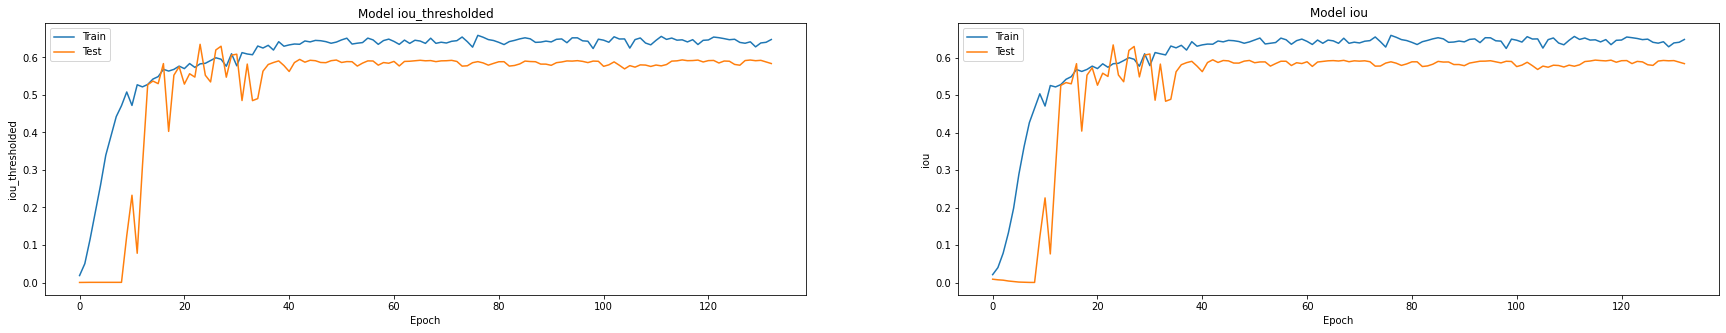

Epoch 1/300
45/45 [==============================] - 8s 185ms/step - loss: 0.9694 - iou: 0.0130 - iou_thresholded: 0.0126 - val_loss: 0.9724 - val_iou: 0.0132 - val_iou_thresholded: 1.7682e-04

Epoch 00001: val_iou_thresholded improved from -inf to 0.00018, saving model to .\5_best_model.h5
Epoch 2/300
45/45 [==============================] - 8s 189ms/step - loss: 0.9474 - iou: 0.0227 - iou_thresholded: 0.0229 - val_loss: 0.9932 - val_iou: 0.0049 - val_iou_thresholded: 2.9430e-04

Epoch 00002: val_iou_thresholded improved from 0.00018 to 0.00029, saving model to .\5_best_model.h5
Epoch 3/300
45/45 [==============================] - 9s 195ms/step - loss: 0.9239 - iou: 0.0333 - iou_thresholded: 0.0352 - val_loss: 0.9988 - val_iou: 0.0010 - val_iou_thresholded: 2.9460e-04

Epoch 00003: val_iou_thresholded improved from 0.00029 to 0.00029, saving model to .\5_best_model.h5
Epoch 4/300
45/45 [==============================] - 8s 188ms/step - loss: 0.8930 - iou: 0.0497 - iou_thresholded: 0.0

45/45 [==============================] - 8s 185ms/step - loss: 0.3122 - iou: 0.6236 - iou_thresholded: 0.6233 - val_loss: 0.2827 - val_iou: 0.6228 - val_iou_thresholded: 0.6214

Epoch 00031: val_iou_thresholded did not improve from 0.62733
Epoch 32/300
45/45 [==============================] - 8s 182ms/step - loss: 0.3122 - iou: 0.6128 - iou_thresholded: 0.6128 - val_loss: 0.2921 - val_iou: 0.6213 - val_iou_thresholded: 0.6200

Epoch 00032: val_iou_thresholded did not improve from 0.62733
Epoch 33/300
45/45 [==============================] - 8s 183ms/step - loss: 0.3332 - iou: 0.5766 - iou_thresholded: 0.5795 - val_loss: 0.2909 - val_iou: 0.6186 - val_iou_thresholded: 0.6169

Epoch 00033: val_iou_thresholded did not improve from 0.62733
Epoch 34/300
45/45 [==============================] - 8s 183ms/step - loss: 0.3505 - iou: 0.5645 - iou_thresholded: 0.5637 - val_loss: 0.2980 - val_iou: 0.6195 - val_iou_thresholded: 0.6187

Epoch 00034: val_iou_thresholded did not improve from 0.62733
E

45/45 [==============================] - 8s 183ms/step - loss: 0.2599 - iou: 0.6680 - iou_thresholded: 0.6668 - val_loss: 0.2932 - val_iou: 0.6262 - val_iou_thresholded: 0.6245 0.2583 - iou: 0.6695 - iou_thresholded: 0.6

Epoch 00062: val_iou_thresholded did not improve from 0.63046
Epoch 63/300
45/45 [==============================] - 8s 187ms/step - loss: 0.2757 - iou: 0.6565 - iou_thresholded: 0.6561 - val_loss: 0.2874 - val_iou: 0.6286 - val_iou_thresholded: 0.6272

Epoch 00063: val_iou_thresholded did not improve from 0.63046
Epoch 64/300
45/45 [==============================] - 8s 185ms/step - loss: 0.2813 - iou: 0.6601 - iou_thresholded: 0.6600 - val_loss: 0.2866 - val_iou: 0.6290 - val_iou_thresholded: 0.6276

Epoch 00064: val_iou_thresholded did not improve from 0.63046
Epoch 65/300
45/45 [==============================] - 8s 184ms/step - loss: 0.2655 - iou: 0.6672 - iou_thresholded: 0.6676 - val_loss: 0.2872 - val_iou: 0.6283 - val_iou_thresholded: 0.6263

Epoch 00065: val_io

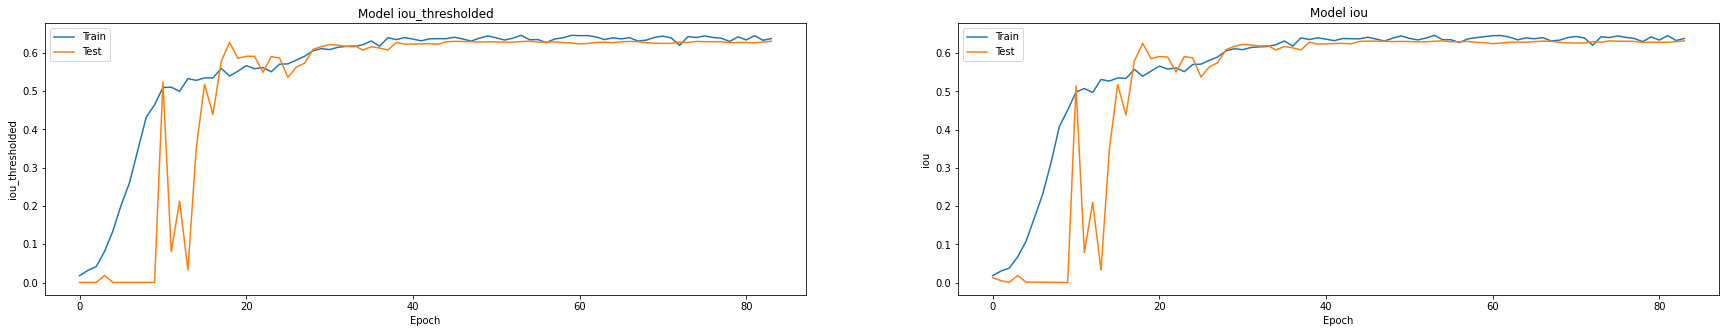

Epoch 1/300
45/45 [==============================] - 8s 186ms/step - loss: 0.9671 - iou: 0.0140 - iou_thresholded: 0.0126 - val_loss: 0.9834 - val_iou: 0.0078 - val_iou_thresholded: 3.9418e-04

Epoch 00001: val_iou_thresholded improved from -inf to 0.00039, saving model to .\6_best_model.h5
Epoch 2/300
45/45 [==============================] - 8s 183ms/step - loss: 0.9240 - iou: 0.0334 - iou_thresholded: 0.0348 - val_loss: 0.9924 - val_iou: 0.0047 - val_iou_thresholded: 9.9605e-04

Epoch 00002: val_iou_thresholded improved from 0.00039 to 0.00100, saving model to .\6_best_model.h5
Epoch 3/300
45/45 [==============================] - 8s 183ms/step - loss: 0.8653 - iou: 0.0632 - iou_thresholded: 0.0795 - val_loss: 0.9970 - val_iou: 0.0022 - val_iou_thresholded: 9.9605e-046 - iou_thresho

Epoch 00003: val_iou_thresholded did not improve from 0.00100
Epoch 4/300
45/45 [==============================] - 8s 184ms/step - loss: 0.8276 - iou: 0.0865 - iou_thresholded: 0.1151 - val_loss: 0.9987 -

45/45 [==============================] - 13s 287ms/step - loss: 0.3233 - iou: 0.5979 - iou_thresholded: 0.5969 - val_loss: 0.6319 - val_iou: 0.3140 - val_iou_thresholded: 0.3134

Epoch 00032: val_iou_thresholded did not improve from 0.36062
Epoch 33/300
45/45 [==============================] - 8s 189ms/step - loss: 0.3048 - iou: 0.6343 - iou_thresholded: 0.6346 - val_loss: 0.6572 - val_iou: 0.2894 - val_iou_thresholded: 0.2885

Epoch 00033: val_iou_thresholded did not improve from 0.36062
Epoch 34/300
45/45 [==============================] - 9s 190ms/step - loss: 0.3581 - iou: 0.5600 - iou_thresholded: 0.5592 - val_loss: 0.6552 - val_iou: 0.2883 - val_iou_thresholded: 0.2878

Epoch 00034: val_iou_thresholded did not improve from 0.36062
Epoch 35/300
45/45 [==============================] - 9s 194ms/step - loss: 0.2819 - iou: 0.6548 - iou_thresholded: 0.6537 - val_loss: 0.7160 - val_iou: 0.2438 - val_iou_thresholded: 0.2439

Epoch 00035: val_iou_thresholded did not improve from 0.36062


45/45 [==============================] - 8s 184ms/step - loss: 0.2727 - iou: 0.6734 - iou_thresholded: 0.6730 - val_loss: 0.6424 - val_iou: 0.3059 - val_iou_thresholded: 0.3066

Epoch 00064: val_iou_thresholded did not improve from 0.36062
Epoch 65/300
45/45 [==============================] - 8s 186ms/step - loss: 0.2486 - iou: 0.6843 - iou_thresholded: 0.6833 - val_loss: 0.6437 - val_iou: 0.3058 - val_iou_thresholded: 0.3056

Epoch 00065: val_iou_thresholded did not improve from 0.36062
Epoch 66/300
45/45 [==============================] - 8s 181ms/step - loss: 0.2701 - iou: 0.6509 - iou_thresholded: 0.6498 - val_loss: 0.6525 - val_iou: 0.3014 - val_iou_thresholded: 0.3022

Epoch 00066: val_iou_thresholded did not improve from 0.36062
Epoch 67/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2554 - iou: 0.6868 - iou_thresholded: 0.6865 - val_loss: 0.6475 - val_iou: 0.3034 - val_iou_thresholded: 0.3033

Epoch 00067: val_iou_thresholded did not improve from 0.36062
E

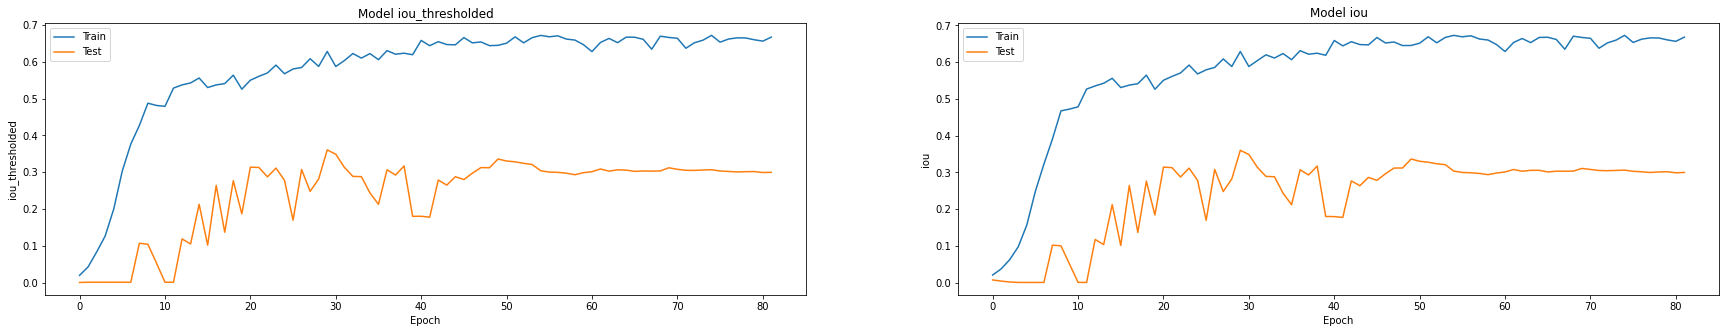

Epoch 1/300
45/45 [==============================] - 9s 192ms/step - loss: 0.9484 - iou: 0.0224 - iou_thresholded: 0.0231 - val_loss: 0.9839 - val_iou: 0.0073 - val_iou_thresholded: 0.0022

Epoch 00001: val_iou_thresholded improved from -inf to 0.00224, saving model to .\7_best_model.h5
Epoch 2/300
45/45 [==============================] - 8s 184ms/step - loss: 0.8477 - iou: 0.0726 - iou_thresholded: 0.1103 - val_loss: 0.9904 - val_iou: 0.0054 - val_iou_thresholded: 0.0023

Epoch 00002: val_iou_thresholded improved from 0.00224 to 0.00229, saving model to .\7_best_model.h5
Epoch 3/300
45/45 [==============================] - 8s 181ms/step - loss: 0.8030 - iou: 0.1017 - iou_thresholded: 0.1563 - val_loss: 0.9945 - val_iou: 0.0036 - val_iou_thresholded: 0.0023

Epoch 00003: val_iou_thresholded did not improve from 0.00229
Epoch 4/300
45/45 [==============================] - 8s 180ms/step - loss: 0.7353 - iou: 0.1514 - iou_thresholded: 0.2040 - val_loss: 0.9969 - val_iou: 0.0022 - val_iou_

45/45 [==============================] - 8s 183ms/step - loss: 0.2902 - iou: 0.6269 - iou_thresholded: 0.6258 - val_loss: 0.5717 - val_iou: 0.4071 - val_iou_thresholded: 0.4096

Epoch 00032: val_iou_thresholded did not improve from 0.62438
Epoch 33/300
45/45 [==============================] - 8s 184ms/step - loss: 0.2913 - iou: 0.6522 - iou_thresholded: 0.6520 - val_loss: 0.5467 - val_iou: 0.4305 - val_iou_thresholded: 0.4348

Epoch 00033: val_iou_thresholded did not improve from 0.62438
Epoch 34/300
45/45 [==============================] - 8s 182ms/step - loss: 0.2740 - iou: 0.6595 - iou_thresholded: 0.6586 - val_loss: 0.5501 - val_iou: 0.4279 - val_iou_thresholded: 0.4295

Epoch 00034: val_iou_thresholded did not improve from 0.62438
Epoch 35/300
45/45 [==============================] - 8s 181ms/step - loss: 0.2867 - iou: 0.6506 - iou_thresholded: 0.6499 - val_loss: 0.5657 - val_iou: 0.4163 - val_iou_thresholded: 0.4181

Epoch 00035: val_iou_thresholded did not improve from 0.62438
E

45/45 [==============================] - 8s 181ms/step - loss: 0.2575 - iou: 0.6811 - iou_thresholded: 0.6802 - val_loss: 0.5226 - val_iou: 0.4508 - val_iou_thresholded: 0.4529- loss: 0.2568 - iou: 0.6821 - iou_thresholded: 0.68

Epoch 00064: val_iou_thresholded did not improve from 0.62438
Epoch 65/300
45/45 [==============================] - 8s 182ms/step - loss: 0.2793 - iou: 0.6443 - iou_thresholded: 0.6433 - val_loss: 0.5236 - val_iou: 0.4492 - val_iou_thresholded: 0.4515

Epoch 00065: val_iou_thresholded did not improve from 0.62438
Epoch 66/300
45/45 [==============================] - 8s 181ms/step - loss: 0.2880 - iou: 0.6357 - iou_thresholded: 0.6348 - val_loss: 0.5551 - val_iou: 0.4197 - val_iou_thresholded: 0.4225

Epoch 00066: val_iou_thresholded did not improve from 0.62438
Epoch 67/300
45/45 [==============================] - 8s 180ms/step - loss: 0.2499 - iou: 0.6894 - iou_thresholded: 0.6888 - val_loss: 0.5819 - val_iou: 0.3959 - val_iou_thresholded: 0.3961

Epoch 00067

45/45 [==============================] - 8s 182ms/step - loss: 0.2853 - iou: 0.6481 - iou_thresholded: 0.6475 - val_loss: 0.5558 - val_iou: 0.4188 - val_iou_thresholded: 0.4212

Epoch 00095: val_iou_thresholded did not improve from 0.62438
Epoch 96/300
45/45 [==============================] - 8s 180ms/step - loss: 0.2867 - iou: 0.6585 - iou_thresholded: 0.6582 - val_loss: 0.5613 - val_iou: 0.4145 - val_iou_thresholded: 0.4169

Epoch 00096: val_iou_thresholded did not improve from 0.62438
Epoch 97/300
45/45 [==============================] - 8s 180ms/step - loss: 0.3075 - iou: 0.6121 - iou_thresholded: 0.6114 - val_loss: 0.5439 - val_iou: 0.4299 - val_iou_thresholded: 0.4329

Epoch 00097: val_iou_thresholded did not improve from 0.62438
Epoch 98/300
45/45 [==============================] - 8s 181ms/step - loss: 0.2834 - iou: 0.6405 - iou_thresholded: 0.6398 - val_loss: 0.5381 - val_iou: 0.4348 - val_iou_thresholded: 0.4383

Epoch 00098: val_iou_thresholded did not improve from 0.62438
E

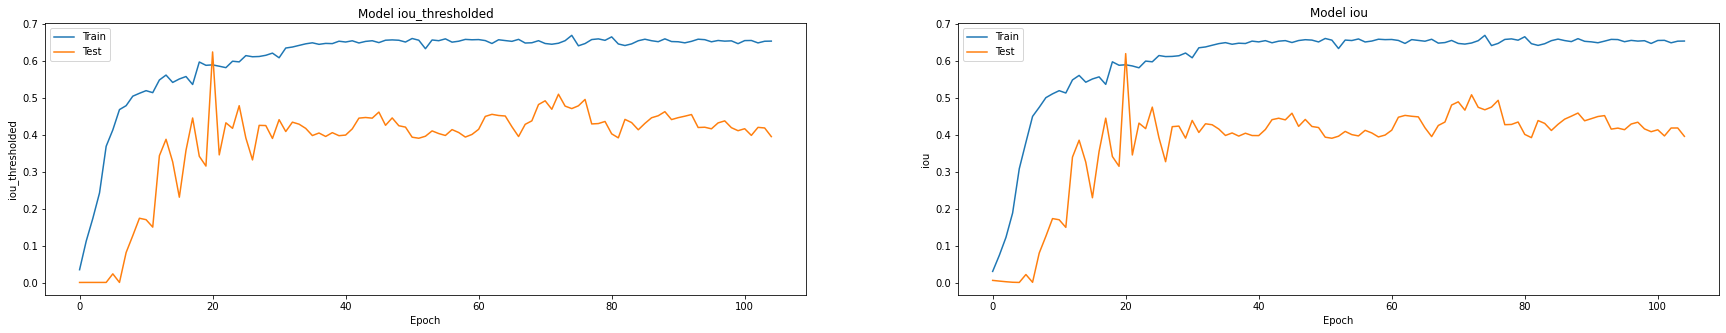

Epoch 1/300
45/45 [==============================] - 8s 179ms/step - loss: 0.9499 - iou: 0.0215 - iou_thresholded: 0.0198 - val_loss: 0.9743 - val_iou: 0.0122 - val_iou_thresholded: 3.5038e-04

Epoch 00001: val_iou_thresholded improved from -inf to 0.00035, saving model to .\8_best_model.h5
Epoch 2/300
45/45 [==============================] - 8s 180ms/step - loss: 0.9037 - iou: 0.0440 - iou_thresholded: 0.0581 - val_loss: 0.9851 - val_iou: 0.0087 - val_iou_thresholded: 5.0613e-04

Epoch 00002: val_iou_thresholded improved from 0.00035 to 0.00051, saving model to .\8_best_model.h5
Epoch 3/300
45/45 [==============================] - 8s 180ms/step - loss: 0.8337 - iou: 0.0849 - iou_thresholded: 0.1188 - val_loss: 0.9985 - val_iou: 6.8656e-04 - val_iou_thresholded: 1.8703e-05thresholded: 0

Epoch 00003: val_iou_thresholded did not improve from 0.00051
Epoch 4/300
45/45 [==============================] - 8s 180ms/step - loss: 0.7586 - iou: 0.1366 - iou_thresholded: 0.1775 - val_loss: 0.996

45/45 [==============================] - 8s 179ms/step - loss: 0.2910 - iou: 0.6249 - iou_thresholded: 0.6241 - val_loss: 0.3124 - val_iou: 0.6121 - val_iou_thresholded: 0.6116

Epoch 00031: val_iou_thresholded did not improve from 0.63840
Epoch 32/300
45/45 [==============================] - 8s 177ms/step - loss: 0.2743 - iou: 0.6653 - iou_thresholded: 0.6644 - val_loss: 0.3339 - val_iou: 0.6270 - val_iou_thresholded: 0.6276

Epoch 00032: val_iou_thresholded did not improve from 0.63840
Epoch 33/300
45/45 [==============================] - 8s 178ms/step - loss: 0.2727 - iou: 0.6548 - iou_thresholded: 0.6539 - val_loss: 0.3708 - val_iou: 0.5906 - val_iou_thresholded: 0.5913

Epoch 00033: val_iou_thresholded did not improve from 0.63840
Epoch 34/300
45/45 [==============================] - 8s 179ms/step - loss: 0.3144 - iou: 0.6082 - iou_thresholded: 0.6116 - val_loss: 0.4229 - val_iou: 0.5389 - val_iou_thresholded: 0.5411

Epoch 00034: val_iou_thresholded did not improve from 0.63840
E

45/45 [==============================] - 8s 179ms/step - loss: 0.2614 - iou: 0.6741 - iou_thresholded: 0.6734 - val_loss: 0.3649 - val_iou: 0.6149 - val_iou_thresholded: 0.6169

Epoch 00063: val_iou_thresholded did not improve from 0.63840
Epoch 64/300
45/45 [==============================] - 8s 184ms/step - loss: 0.2563 - iou: 0.6930 - iou_thresholded: 0.6957 - val_loss: 0.3712 - val_iou: 0.6094 - val_iou_thresholded: 0.6108sholded: 0.69

Epoch 00064: val_iou_thresholded did not improve from 0.63840
Epoch 65/300
45/45 [==============================] - 8s 187ms/step - loss: 0.2527 - iou: 0.6720 - iou_thresholded: 0.6709 - val_loss: 0.3565 - val_iou: 0.6217 - val_iou_thresholded: 0.6236

Epoch 00065: val_iou_thresholded did not improve from 0.63840
Epoch 66/300
45/45 [==============================] - 8s 179ms/step - loss: 0.3274 - iou: 0.5868 - iou_thresholded: 0.5862 - val_loss: 0.3790 - val_iou: 0.6029 - val_iou_thresholded: 0.6048

Epoch 00066: val_iou_thresholded did not improve f

45/45 [==============================] - 8s 178ms/step - loss: 0.3047 - iou: 0.6274 - iou_thresholded: 0.6278 - val_loss: 0.3565 - val_iou: 0.6207 - val_iou_thresholded: 0.6231

Epoch 00095: val_iou_thresholded did not improve from 0.63840
Epoch 96/300
45/45 [==============================] - 8s 180ms/step - loss: 0.2995 - iou: 0.6109 - iou_thresholded: 0.6098 - val_loss: 0.3836 - val_iou: 0.5987 - val_iou_thresholded: 0.60120.3251 - iou: 0.57

Epoch 00096: val_iou_thresholded did not improve from 0.63840
Epoch 97/300
45/45 [==============================] - 8s 181ms/step - loss: 0.2671 - iou: 0.6655 - iou_thresholded: 0.6647 - val_loss: 0.3781 - val_iou: 0.6034 - val_iou_thresholded: 0.6052

Epoch 00097: val_iou_thresholded did not improve from 0.63840
Epoch 98/300
45/45 [==============================] - 9s 207ms/step - loss: 0.2740 - iou: 0.6462 - iou_thresholded: 0.6453 - val_loss: 0.3812 - val_iou: 0.6014 - val_iou_thresholded: 0.6025

Epoch 00098: val_iou_thresholded did not impr

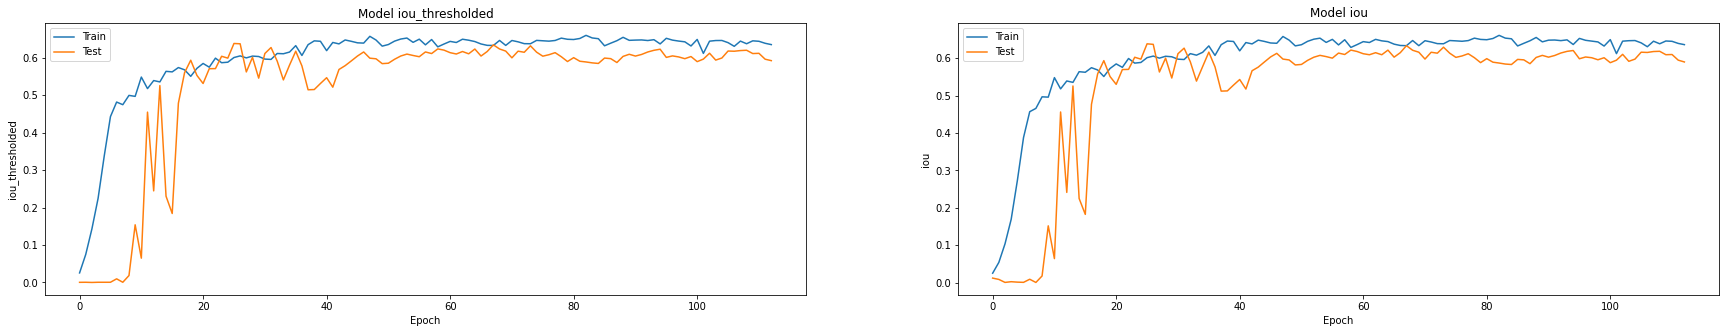

Epoch 1/300
45/45 [==============================] - 8s 185ms/step - loss: 0.9565 - iou: 0.0186 - iou_thresholded: 0.0169 - val_loss: 0.9771 - val_iou: 0.0113 - val_iou_thresholded: 3.1107e-04

Epoch 00001: val_iou_thresholded improved from -inf to 0.00031, saving model to .\9_best_model.h5
Epoch 2/300
45/45 [==============================] - 8s 182ms/step - loss: 0.9313 - iou: 0.0307 - iou_thresholded: 0.0367 - val_loss: 0.9995 - val_iou: 3.2511e-04 - val_iou_thresholded: 1.1307e-04.9389 - iou: 0.0270 - iou_threshold

Epoch 00002: val_iou_thresholded did not improve from 0.00031
Epoch 3/300
45/45 [==============================] - 8s 181ms/step - loss: 0.8399 - iou: 0.0796 - iou_thresholded: 0.1023 - val_loss: 0.9994 - val_iou: 5.9147e-04 - val_iou_thresholded: 3.9115e-040799 - iou_thresholded

Epoch 00003: val_iou_thresholded improved from 0.00031 to 0.00039, saving model to .\9_best_model.h5
Epoch 4/300
45/45 [==============================] - 8s 186ms/step - loss: 0.8063 - iou: 0.1


Epoch 00030: val_iou_thresholded did not improve from 0.45982
Epoch 31/300
45/45 [==============================] - 8s 180ms/step - loss: 0.3421 - iou: 0.5762 - iou_thresholded: 0.5756 - val_loss: 0.5323 - val_iou: 0.4607 - val_iou_thresholded: 0.4618

Epoch 00031: val_iou_thresholded improved from 0.45982 to 0.46182, saving model to .\9_best_model.h5
Epoch 32/300
45/45 [==============================] - 8s 180ms/step - loss: 0.3256 - iou: 0.6020 - iou_thresholded: 0.6018 - val_loss: 0.5557 - val_iou: 0.4388 - val_iou_thresholded: 0.4404

Epoch 00032: val_iou_thresholded did not improve from 0.46182
Epoch 33/300
45/45 [==============================] - 8s 182ms/step - loss: 0.2989 - iou: 0.6337 - iou_thresholded: 0.6330 - val_loss: 0.5338 - val_iou: 0.4566 - val_iou_thresholded: 0.45732913 - iou: 0.6438 - iou_thresh

Epoch 00033: val_iou_thresholded did not improve from 0.46182
Epoch 34/300
45/45 [==============================] - 9s 211ms/step - loss: 0.3244 - iou: 0.6052 - iou_thres

45/45 [==============================] - 8s 182ms/step - loss: 0.2576 - iou: 0.6807 - iou_thresholded: 0.6802 - val_loss: 0.5372 - val_iou: 0.4534 - val_iou_thresholded: 0.4541 loss: 0.2641 - iou: 

Epoch 00061: val_iou_thresholded did not improve from 0.51384
Epoch 62/300
45/45 [==============================] - 8s 183ms/step - loss: 0.2611 - iou: 0.6740 - iou_thresholded: 0.6731 - val_loss: 0.5397 - val_iou: 0.4529 - val_iou_thresholded: 0.4533

Epoch 00062: val_iou_thresholded did not improve from 0.51384
Epoch 63/300
45/45 [==============================] - 8s 180ms/step - loss: 0.2762 - iou: 0.6558 - iou_thresholded: 0.6555 - val_loss: 0.5361 - val_iou: 0.4565 - val_iou_thresholded: 0.4572

Epoch 00063: val_iou_thresholded did not improve from 0.51384
Epoch 64/300
45/45 [==============================] - 9s 196ms/step - loss: 0.2512 - iou: 0.6801 - iou_thresholded: 0.6793 - val_loss: 0.5280 - val_iou: 0.4613 - val_iou_thresholded: 0.4620

Epoch 00064: val_iou_thresholded did not i

45/45 [==============================] - 8s 180ms/step - loss: 0.2445 - iou: 0.6907 - iou_thresholded: 0.6902 - val_loss: 0.5327 - val_iou: 0.4583 - val_iou_thresholded: 0.4588

Epoch 00093: val_iou_thresholded did not improve from 0.51384
Epoch 94/300
45/45 [==============================] - 8s 180ms/step - loss: 0.2579 - iou: 0.6629 - iou_thresholded: 0.6622 - val_loss: 0.5287 - val_iou: 0.4607 - val_iou_thresholded: 0.4613

Epoch 00094: val_iou_thresholded did not improve from 0.51384
Epoch 95/300
45/45 [==============================] - 8s 182ms/step - loss: 0.2456 - iou: 0.6873 - iou_thresholded: 0.6865 - val_loss: 0.5319 - val_iou: 0.4588 - val_iou_thresholded: 0.4596

Epoch 00095: val_iou_thresholded did not improve from 0.51384
Epoch 96/300
45/45 [==============================] - 8s 182ms/step - loss: 0.2427 - iou: 0.6964 - iou_thresholded: 0.6956 - val_loss: 0.5277 - val_iou: 0.4614 - val_iou_thresholded: 0.4617

Epoch 00096: val_iou_thresholded did not improve from 0.51384
E

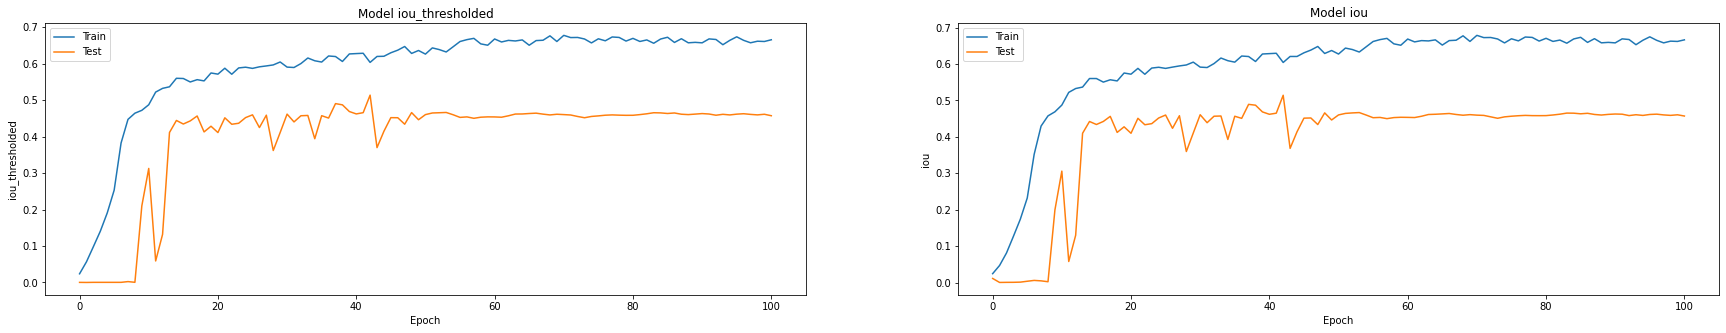

Epoch 1/300
45/45 [==============================] - 9s 194ms/step - loss: 0.9550 - iou: 0.0194 - iou_thresholded: 0.0154 - val_loss: 0.9762 - val_iou: 0.0106 - val_iou_thresholded: 2.2925e-04

Epoch 00001: val_iou_thresholded improved from -inf to 0.00023, saving model to .\10_best_model.h5
Epoch 2/300
45/45 [==============================] - 8s 182ms/step - loss: 0.9033 - iou: 0.0439 - iou_thresholded: 0.0600 - val_loss: 0.9899 - val_iou: 0.0061 - val_iou_thresholded: 4.8021e-04 iou: 0.0408 - iou_threshol

Epoch 00002: val_iou_thresholded improved from 0.00023 to 0.00048, saving model to .\10_best_model.h5
Epoch 3/300
45/45 [==============================] - 8s 179ms/step - loss: 0.8392 - iou: 0.0789 - iou_thresholded: 0.1143 - val_loss: 0.9975 - val_iou: 0.0018 - val_iou_thresholded: 4.8021e-04

Epoch 00003: val_iou_thresholded did not improve from 0.00048
Epoch 4/300
45/45 [==============================] - 8s 188ms/step - loss: 0.7882 - iou: 0.1177 - iou_thresholded: 0.1529 - val_

45/45 [==============================] - 8s 180ms/step - loss: 0.3434 - iou: 0.5751 - iou_thresholded: 0.5745 - val_loss: 0.2620 - val_iou: 0.6357 - val_iou_thresholded: 0.6346

Epoch 00031: val_iou_thresholded did not improve from 0.65747
Epoch 32/300
45/45 [==============================] - 8s 181ms/step - loss: 0.3012 - iou: 0.6154 - iou_thresholded: 0.6143 - val_loss: 0.2694 - val_iou: 0.6292 - val_iou_thresholded: 0.6276

Epoch 00032: val_iou_thresholded did not improve from 0.65747
Epoch 33/300
45/45 [==============================] - 8s 180ms/step - loss: 0.3417 - iou: 0.5864 - iou_thresholded: 0.5858 - val_loss: 0.3585 - val_iou: 0.5406 - val_iou_thresholded: 0.5405

Epoch 00033: val_iou_thresholded did not improve from 0.65747
Epoch 34/300
45/45 [==============================] - 8s 182ms/step - loss: 0.3229 - iou: 0.5920 - iou_thresholded: 0.5911 - val_loss: 0.2994 - val_iou: 0.6124 - val_iou_thresholded: 0.6121

Epoch 00034: val_iou_thresholded did not improve from 0.65747
E

45/45 [==============================] - 8s 180ms/step - loss: 0.2507 - iou: 0.6940 - iou_thresholded: 0.6934 - val_loss: 0.2621 - val_iou: 0.6617 - val_iou_thresholded: 0.6609

Epoch 00063: val_iou_thresholded did not improve from 0.68707
Epoch 64/300
45/45 [==============================] - 8s 179ms/step - loss: 0.2725 - iou: 0.6532 - iou_thresholded: 0.6525 - val_loss: 0.2606 - val_iou: 0.6624 - val_iou_thresholded: 0.6615

Epoch 00064: val_iou_thresholded did not improve from 0.68707
Epoch 65/300
45/45 [==============================] - 8s 178ms/step - loss: 0.2579 - iou: 0.6779 - iou_thresholded: 0.6769 - val_loss: 0.2535 - val_iou: 0.6654 - val_iou_thresholded: 0.6644

Epoch 00065: val_iou_thresholded did not improve from 0.68707
Epoch 66/300
45/45 [==============================] - 8s 187ms/step - loss: 0.2554 - iou: 0.6706 - iou_thresholded: 0.6697 - val_loss: 0.2552 - val_iou: 0.6660 - val_iou_thresholded: 0.6655

Epoch 00066: val_iou_thresholded did not improve from 0.68707
E

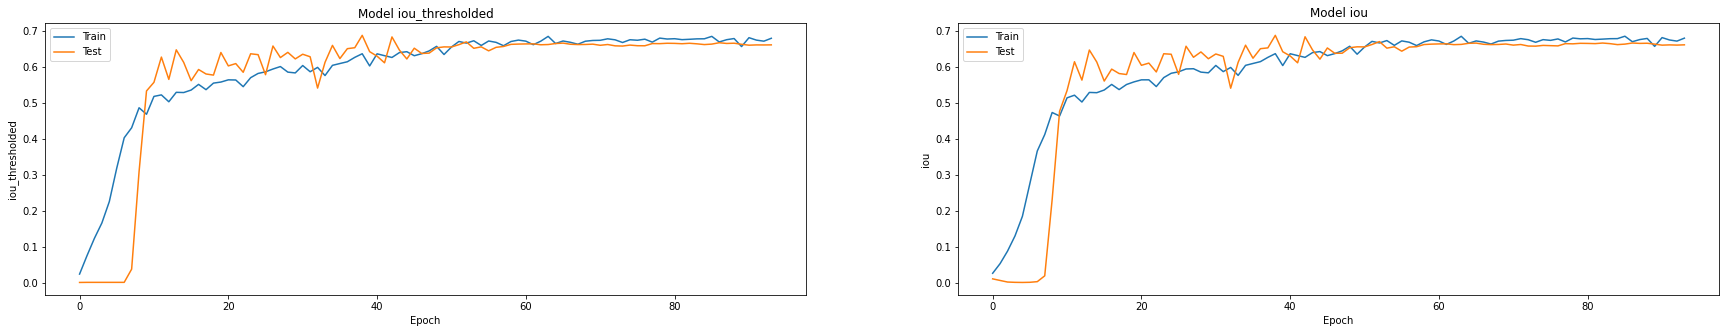

In [8]:


tf.config.run_functions_eagerly(True)
kf = KFold(n_splits = 10)

BATCH_SIZE = 1
EPOCHS = 300

i = 0
for train_index, val_index in kf.split(X):
    i += 1
    
    # Callbacks
    callbacks = [
                tf.keras.callbacks.ModelCheckpoint('./'+ str(i) +'_best_model.h5', 
                                                   monitor = 'val_iou_thresholded', mode = 'max',
                                                   save_best_only = True, verbose = 1),
                tf.keras.callbacks.ReduceLROnPlateau(),
                tf.keras.callbacks.EarlyStopping(monitor = 'loss', patience = 30)
            ]

    
    # Creating the model
    model = custom_unet(img_dim, 
                        num_classes=1,
                        activation="swish",
                        filters=8, 
                        num_layers=4)

    # Compile
    model.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate=1e-3), 
                  loss = focal_tversky_loss, 
                  metrics = [iou, iou_thresholded])


    # Train model
    history = model.fit(
                X[train_index,:,:,:], 
                Y[train_index,:,:,:], 
                validation_data=(X[val_index,:,:,:],Y[val_index,:,:,:]), 
                batch_size=BATCH_SIZE, 
                epochs=EPOCHS, 
                callbacks=callbacks,
                verbose=1)


    # Plot training & validation iou_score values
    plt.figure(figsize=(30, 5))
    plt.subplot(121)
    plt.plot(history.history['iou_thresholded'])
    plt.plot(history.history['val_iou_thresholded'])
    plt.title('Model iou_thresholded')
    plt.ylabel('iou_thresholded')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(122)
    plt.plot(history.history['iou'])
    plt.plot(history.history['val_iou'])
    plt.title('Model iou')
    plt.ylabel('iou')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    plt.show()




split 5 0.63489
split 6 0.36062
split 7 0.62438
split 8 0.63840
split 9 0.51384
split 10 0.68707

## Model Evaluation

In [9]:
## Prediction
#model = tf.keras.models.load_model(''.join(["./", "01_model.h5"]), compile=False)
Y_pred = model.predict(X[idx_test,:,:,:])
Y_pred[Y_pred >= 0.3] = 1
Y_pred[Y_pred < 0.3] = 0

In [20]:
# Evaluation functions
def iou_coef(y_true, y_pred, smooth=1):
    intersection = K.sum(K.abs(y_true * y_pred), axis=[1,2,3])
    union = K.sum(y_true,[1,2,3])+K.sum(y_pred,[1,2,3])-intersection
    iou = K.mean((intersection + smooth) / (union + smooth), axis=0)
    return iou

def dice_coef(y_true, y_pred, smooth=1):
    intersection = K.sum(y_true * y_pred, axis=[1,2,3])
    union = K.sum(y_true, axis=[1,2,3]) + K.sum(y_pred, axis=[1,2,3])
    dice = K.mean((2. * intersection + smooth)/(union + smooth), axis=0)
    return dice


# Perfomance results 
print('Dice coef: ' + str(dice_coef(tf.cast(Y[idx_test], dtype=Y_pred.dtype), Y_pred, smooth=1).numpy()))
print('IOU coef: ' + str(iou_coef(tf.cast(Y[idx_test], dtype=Y_pred.dtype), Y_pred, smooth=1).numpy()))

Dice coef: 0.5766154
IOU coef: 0.45401147


## Visualization of results on test dataset

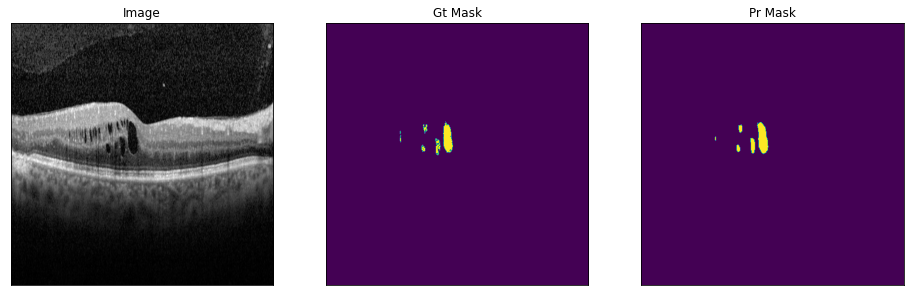

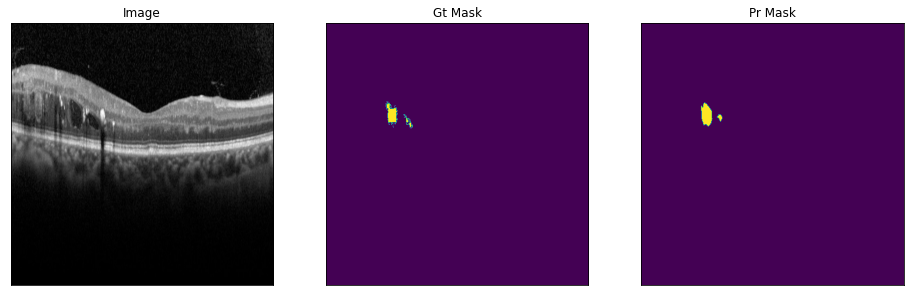

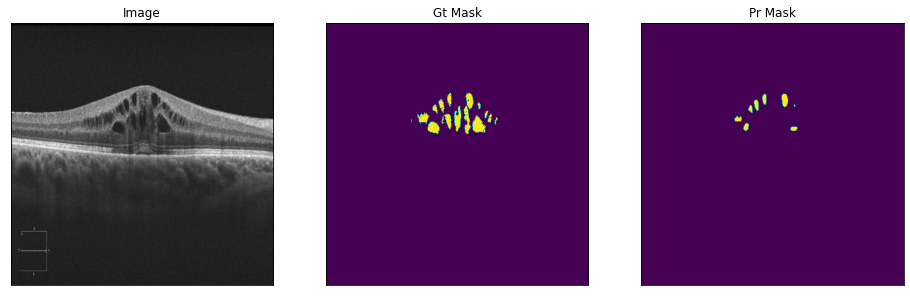

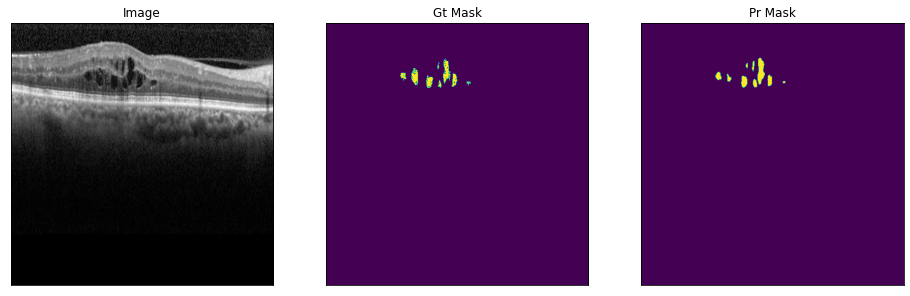

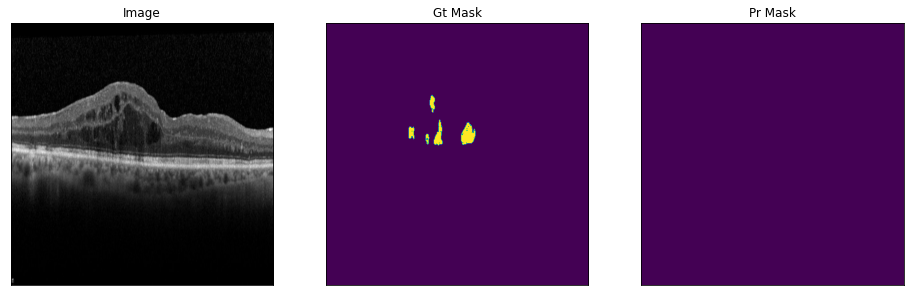

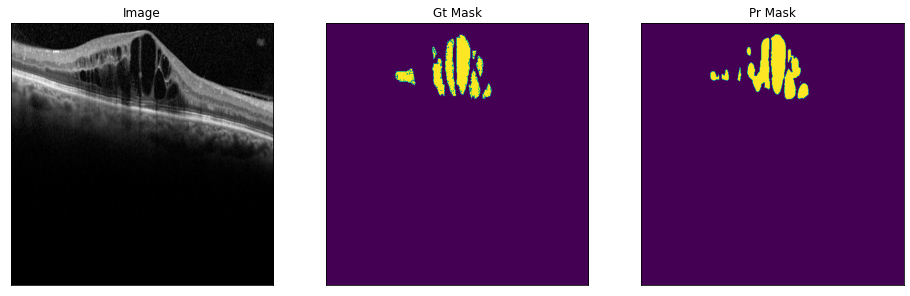

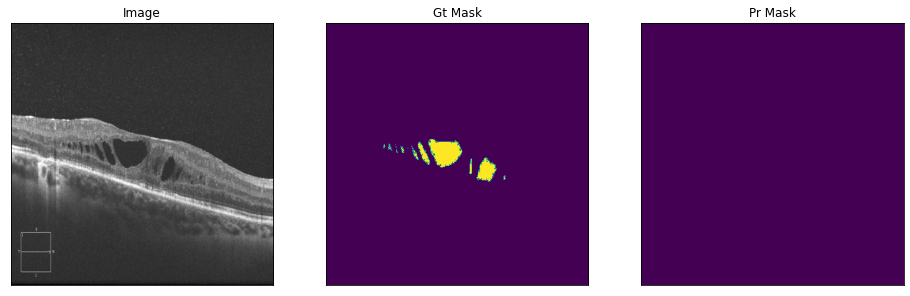

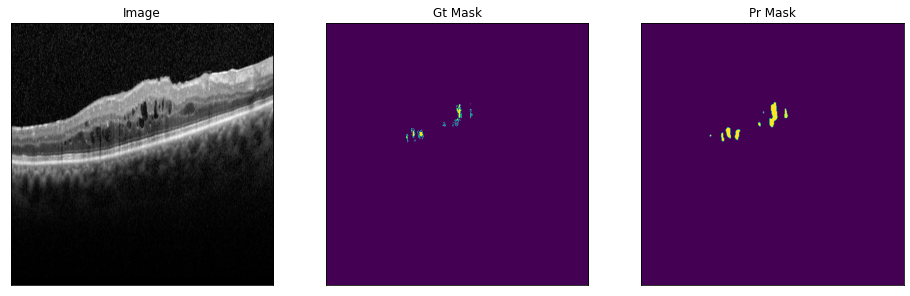

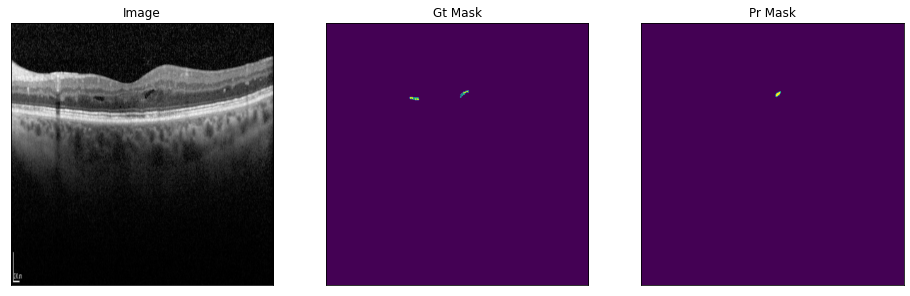

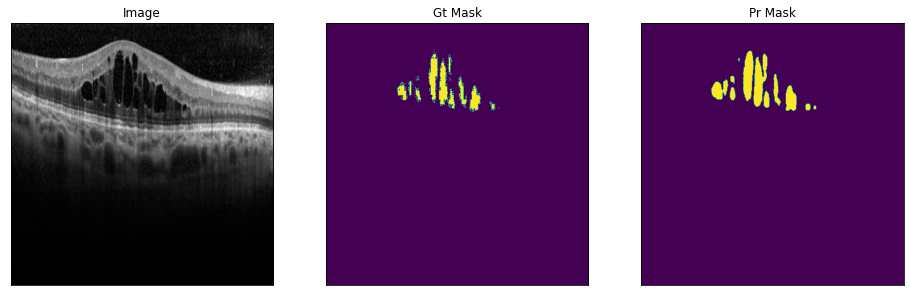

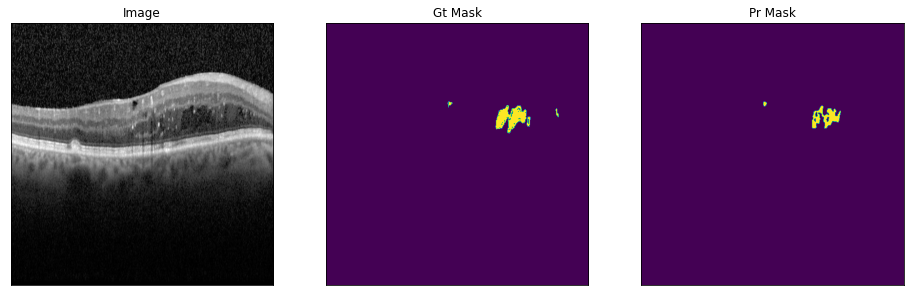

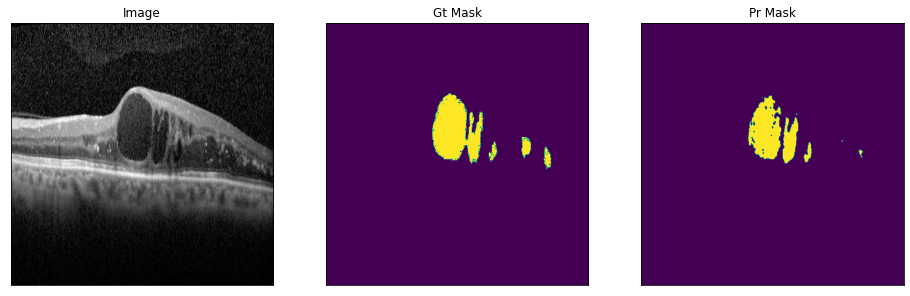

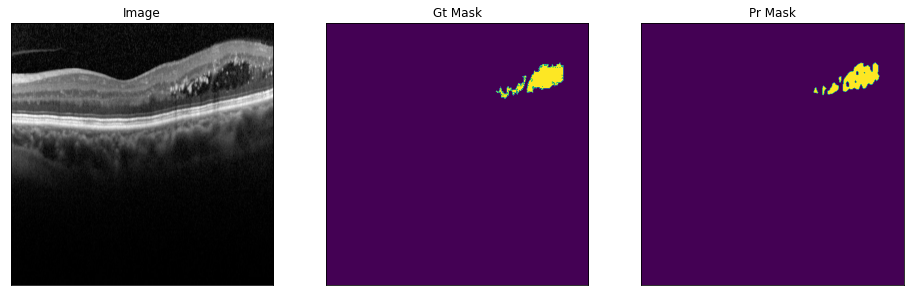

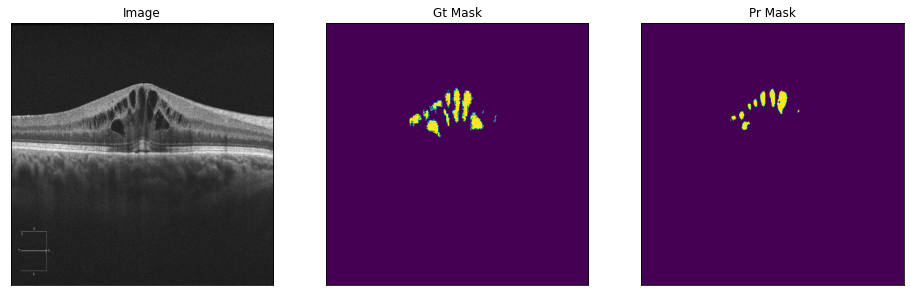

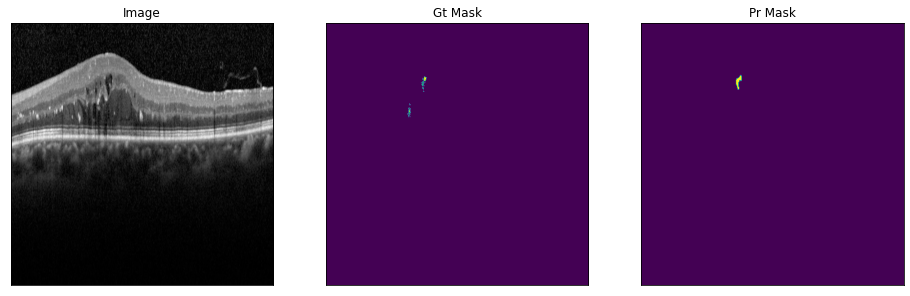

In [25]:
## 

# helper function for data visualization
def visualize(**images):
    """PLot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(' '.join(name.split('_')).title())
        plt.imshow(image)
    plt.show()
    
# n = 5
# ids = np.random.choice(np.arange(len(idx_test)), size=n)

for i in range(len(idx_test)):
    
    image = X[idx_test][i]
    gt_mask = Y[idx_test][i]
    pr_mask = Y_pred[i]
    
    visualize(
        image=image.squeeze(),
        gt_mask=gt_mask[..., 0].squeeze(),
        pr_mask=pr_mask[..., 0].squeeze(),
    )